<a href="https://colab.research.google.com/github/pc-repo/algorytmy-ewolucyjne/blob/main/AE_L6_65456.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AE_Lab_6**
Wspomaganie procesów optymalizacyjnych z wykorzystaniem AE

###**Zad. 1.** Korzystając z biblioteki *gplearn* napisz program w *Python* implementujący genetyczne programowanie do prognozowania cen akcji na podstawie szeregu cen akcji na zamknięciu amerykańskiej giełdy NASDAQ.

### Biblioteka `gplearn` – Symboliczna Regresja w Pythonie

**`gplearn`** to biblioteka w Pythonie służąca do **symbolicznej regresji i klasyfikacji** z wykorzystaniem **genetycznego programowania (Genetic Programming, GP)**. Umożliwia znajdowanie matematycznych modeli opisujących dane w formie wyrażeń symbolicznych, np.:

$y = x_1 \cdot \sin(x_2) + 3$

### Zastosowania:
- **Regresja symboliczna** – znajdowanie równań opisujących dane,
- **Klasyfikacja symboliczna** – klasyfikatory jako kombinacje funkcji matematycznych,
- **Modele interpretowalne** – przezroczyste alternatywy dla modeli typu "czarna skrzynka".

### Kluczowe cechy:
- Interfejs wzorowany na `scikit-learn` – łatwa integracja,
- Ewolucja populacji wyrażeń przez:
  - selekcję,
  - krzyżowanie (crossover),
  - mutację (subtree, hoist, point),
- Obsługa własnych funkcji matematycznych,
- Parsymonia – karanie złożonych modeli (kontrola nadprzeciętnej złożoności),
- Ograniczenia głębokości drzew i rodzaju funkcji.

### Główne klasy:
- `SymbolicRegressor` – do regresji,
- `SymbolicClassifier` – do klasyfikacji,
- `SymbolicTransformer` – do ekstrakcji nieliniowych cech.

---

Link do dokumentacji: https://gplearn.readthedocs.io/


### Opis danych giełdowych

Dane pochodzą z amerykańskiej giełdy **NASDAQ**, jednej z największych elektronicznych giełd papierów wartościowych na świecie. Obejmują one notowania spółek technologicznych i innych firm o dużej kapitalizacji.

**Przykładowe symbole firm używane w analizie:**

- **Stabilne spółki (blue chip):**
  - `AAPL` – Apple Inc.
  - `MSFT` – Microsoft Corporation
  - `GOOGL` – Alphabet Inc. (Google)

- **Niestabilne spółki (wysoka zmienność):**
  - `TSLA` – Tesla, Inc.
  - `NVDA` – NVIDIA Corporation
  - `RIVN` – Rivian Automotive, Inc.

### Oficjalne konta GitHub firm o wysokiej zmienności

- [Tesla, Inc.](https://github.com/teslamotors)
- [NVIDIA Corporation](https://github.com/NVIDIA)
- [Rivian Automotive, Inc.](https://github.com/rivian)

In [ ]:
# Instalowanie bibliotek
!pip -q install gplearn

Poniżej znajdują się importy wykorzystanych bibliotek.

In [ ]:
# Import bibliotek
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gplearn.genetic import SymbolicRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

Pobranie oficjalnych danych giełdowych spółki Apple Inc. z notowań NASDAQ przez parsowanie kolumn spod adresu przypisanego do 'url' i przypisanie ich do zmiennej 'data' używając biblioteki 'pandas'.

In [ ]:
# Wczytanie danych
url = "https://raw.githubusercontent.com/kishoreramakrishnan-ds/stock-market-analysis-aapl/main/AAPL.csv"
data = pd.read_csv(url, parse_dates=['Date'], index_col='Date')

Listowanie pobranych danych dotyczących notowań z użyciem 'pandas'. Wykorzystywany do przewidywań parametr to tzw. kurs zamknięcia, który jest wyświetlany jako 'Close'.

In [ ]:
# Wyświetlenie notowań

pd.set_option('display.width', 180)
print(f"Wzorzec danych: \n {data.head()}")        # Notowania
print(f"\nInfo Dataset:\n")
print(data.info(), "\n")                          # Typy danych  w tabeli
print(f"Statystyki opisowe:\n", data.describe())  # Tabela statystyk

Wzorzec danych: 
                  Open       High        Low      Close  Adj Close     Volume
Date                                                                        
2019-08-16  51.070000  51.790001  50.959999  51.625000  49.954624  110481600
2019-08-19  52.654999  53.182499  52.507500  52.587502  50.885971   97654400
2019-08-20  52.720001  53.337502  52.580002  52.590000  50.888390  107537200
2019-08-21  53.247501  53.412498  52.900002  53.160000  51.439960   86141600
2019-08-22  53.297501  53.610001  52.687500  53.115002  51.396420   89014800

Info Dataset:

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2019-08-16 to 2024-08-15
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       1258 non-null   float64
 1   High       1258 non-null   float64
 2   Low        1258 non-null   float64
 3   Close      1258 non-null   float64
 4   Adj Close  1258 non-null   float64
 5   Volume     1258 no

Pobranie notowań zamknięcia - 'Close' bez uwzględniania brakujących wartości. A także tworzenie szeregu czasowego wartości opóźnionych X[ ] oraz przewidywanych Y[ ]. Zdefiniowanie tych wektorów na podstawie pobranych danych notowań spółki.

In [ ]:
# Kolumna z wierszami
close_prices = data['Close'].dropna().values

# Tworzenie zmiennych z uwzględnieniem kolejności wprowadzania - opóźnionych
def create_lag_features(y, lag):
  X = []
  Y = []
  for i in range(lag, len(y)):  # Pętla od lag do końca serii 'y'
    X.append(y[i-lag:i])        # 'lag' poprzednich wartości
    Y.append(y[i])              # Wartość do predykcji
  return np.array(X), np.array(Y)

lag = 10                        # Ilość pobieranych opóźnionych wartości

X, Y = create_lag_features(close_prices, lag)   # Wczytanie wektorów danych inicjujących.

In [ ]:
# Wyświetlenie danych zamknięcia 'Close'

np.set_printoptions(linewidth=300)
close_prices[:10]

array([51.625   , 52.587502, 52.59    , 53.16    , 53.115002, 50.66    , 51.622501, 51.040001, 51.3825  , 52.252499])

In [ ]:
# Wyświetlenie wektorów inicjujących X i Y

print(X)
print(f"\n", Y)

[[ 51.625     52.587502  52.59     ...  51.040001  51.3825    52.252499]
 [ 52.587502  52.59      53.16     ...  51.3825    52.252499  52.185001]
 [ 52.59      53.16      53.115002 ...  52.252499  52.185001  51.424999]
 ...
 [218.800003 222.080002 218.360001 ... 213.309998 216.240005 217.529999]
 [222.080002 218.360001 219.860001 ... 216.240005 217.529999 221.270004]
 [218.360001 219.860001 209.270004 ... 217.529999 221.270004 221.720001]]

 [ 52.185001  51.424999  52.297501 ... 221.270004 221.720001 224.720001]


Tablica X to tablica wektorów, natomiast Y to tablica pojedyncztch wartości. Dlatego chcąc normalizować wartości używamy dwóch różnych dedykowanych funkcji. Do normalizacji używamy tzw. skalerów.

In [ ]:
# Normalizacja (skalowanie) danych

scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
scaler_Y = StandardScaler()
Y_scaled = scaler_Y.fit_transform(Y.reshape(-1, 1)).ravel()

Kolejnym krokiem jest podział danych na grupę uczącą oraz testową. Tu jest to relacja 80% danych uczących do 20% danych testowych.

In [ ]:
# Definicja zbioru uczącego i testowego

train_size = int(0.8 * len(Y))
X_train, X_test = X_scaled[:train_size], X_scaled[train_size:]
y_train, y_test = Y_scaled[:train_size], Y_scaled[train_size:]

Definicja modelu regresji biblioteki 'gplearn' - kolejne parametry, pod nazwą SymbolicRegressor. Mutacja dotyczy tu drzew wyrażeń złożonych z pojedynczych działań arytmetycznych.

In [ ]:
# Definicja modelu zagadnienia

model = SymbolicRegressor(
    population_size=50,               # Populacja
    generations=200,                  # Generacje
    tournament_size=20,               # Rozmiar turnieju
    stopping_criteria=0.01,           # Kryterium zatrzymania - wystarczająca dokładność
    function_set=('add', 'sub', 'mul', 'div', 'sin', 'cos'),    # Możliwe funkcje dopasowania
    p_crossover=0.7,                  # Krzyżowanie
    p_subtree_mutation=0.1,           # Mutacja całego drzewa
    p_hoist_mutation=0.05,            # Mutacja hoist - losowa zamiana poddrzew
    p_point_mutation=0.1,             # Mutacja punktowa
    max_samples=0.9,                  # Procent danych treningowych
    verbose=1,                        # Sposób wyświetlania wyników
    parsimony_coefficient=0.01,       # Kara za komplikowanie drzewa
    random_state=1                    # Zestaw parametrów
)

Poniżej model treningowy.

In [ ]:
# Proces uczenia - dane treningowe

model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    15.80           9.0502        3         0.178389         0.193606      9.81s
   1     3.00          0.40978        1        0.0753203        0.0913061      7.41s
   2     1.54         0.135608        1         0.075325        0.0912645      7.01s
   3     1.54         0.176808        1        0.0756589        0.0882659      9.21s
   4     1.30          0.18447        1        0.0752644        0.0918081      8.52s
   5     1.40         0.226165        1        0.0750704        0.0935507      7.49s
   6     1.34         0.169093        1        0.0643159        0.0656752      7.44s
   7     1.34         0.221213        1        0.0637421        0.0708275      6.59s
   8     1.20         0.110096        1        0.0634465        0.0734818  

SymbolicRegressor(function_set=('add', 'sub', 'mul', 'div', 'sin', 'cos'),
                  generations=200, max_samples=0.9, p_crossover=0.7,
                  p_hoist_mutation=0.05, p_point_mutation=0.1,
                  p_subtree_mutation=0.1, parsimony_coefficient=0.01,
                  population_size=50, random_state=1, stopping_criteria=0.01,
                  verbose=1)

Terminal to najprostszy składnik wyrażenia matematycznego – czyli element, który nie ma żadnych dzieci w drzewie składniowym

Odpowiedź modelu: ***następna cena to taka sama jak ostatnia znana***

Kod wykonuje przewidywanie (predykcję) na danych testowych, odwraca skalowanie wyników, aby uzyskać wartości w oryginalnej skali.

In [ ]:
# Predykcja

y_pred_scaled = model.predict(X_test)
y_pred = scaler_Y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
y_true = close_prices[lag + train_size:]

Kod wyświetla błąd średni kwadratowy dla oceny rozwiązania 'mse' oraz wykorzystaną w modelu funkcję predykcji.

In [ ]:
# Ocena
mse = mean_squared_error(y_true, y_pred)
print(f"MSE: {mse:.2f}")
print(f"Funkcja GP:", model._program)

MSE: 7.50
Funkcja GP: X9


Reprezentacja graficzna zagadnienia

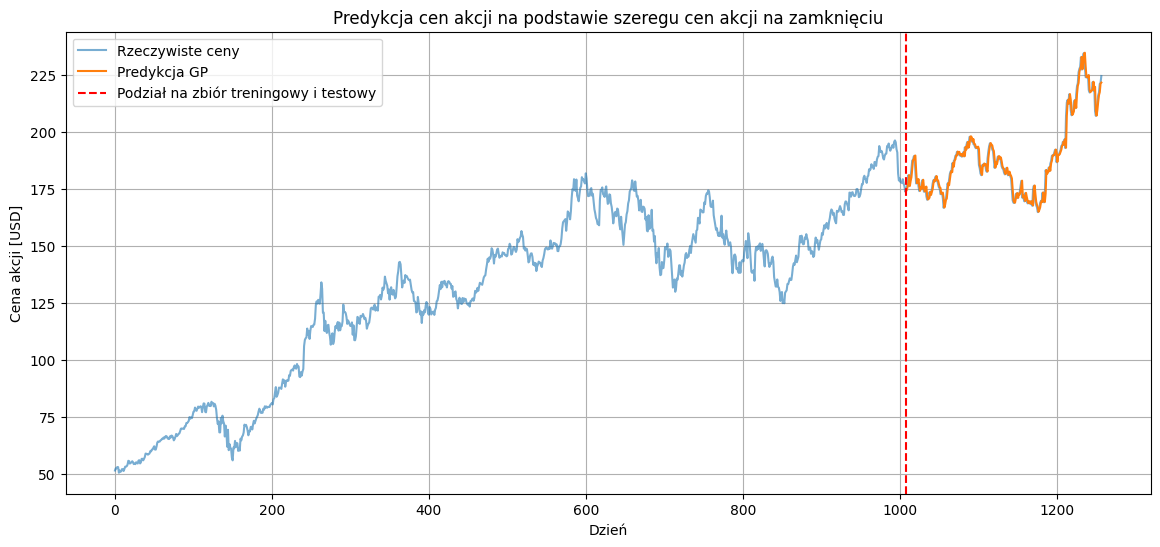

In [ ]:
# Wykres
plt.figure(figsize=(14, 6))
plt.plot(close_prices, label='Rzeczywiste ceny', alpha=0.6)
plt.plot(range(lag + train_size, lag + train_size + len(y_pred)), y_pred, label='Predykcja GP')
plt.axvline(x=lag + train_size, color='r', linestyle='--', label='Podział na zbiór treningowy i testowy')
plt.title("Predykcja cen akcji na podstawie szeregu cen akcji na zamknięciu")
plt.xlabel("Dzień")
plt.ylabel("Cena akcji [USD]")
plt.legend()
plt.grid(True)
plt.show()

Osiągnięty średni błąd kwadratowy wyniósł 7.50 przy użytej w modelu funkcji liniowej, gdzie do prognozy jest wykorzystywany ostatni znany wynik. Jest to możliwe ze względu na stabilność notowań spółki. Rozwiązanie jest trywialne.

###**Zad. 2.** Korzystając z biblioteki *geneticalgorithm* napisz program w *Python* implementujący algorytm ewolucyjny do znajdowania optymalnych parametrów perceptrona wielowarstwowego **MLP** do klasyfikacji odmian kwiatów irysa.

In [ ]:
pip install -q geneticalgorithm

Poniżej znajdują się importy wykorzystanych bibliotek.

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from geneticalgorithm import geneticalgorithm as ga

Zaczytanie danych inicjujących, wyznaczenie zakresu danych uczących i testowych oraz skalowanie tych danych.

In [ ]:
# Wczytaj dane

data = load_iris()
X = data.data
y = data.target

# Poddział trening - test (relacja 70/30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# Skalowanie
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Definicja zakresów inicjacyjnych.

In [ ]:
# Zakres parametrów optymalizacji

var = np.array([
    [1, 10],  # Liczba neuronów w warstwie ukrytej 1
    [0, 10],  # Liczba neuronów w warstwie ukrytej 2
    [0.0001, 0.3], # Współczynnik uczenia - learning rate
    [0, 1], # Solver - optymalizator (tu: 'adam' lub 'sgd')
    [0, 3], # Funkcja aktywacji (tu: identity, logistic, tanh lub relu)
])

Definicja funkcji celu jest inicjowana listą params[] - 5 elementowa, indeksowana od zera.

In [ ]:
def fitness_function(params):         # Funkcja celu z przekazaniem parametrów
    hl1 = int(params[0])              # Ilość neuronów ukrytej warstwy 1
    hl2 = int(params[1])              # Ilość neuronów ukrytej warstwy 2
    learning_rate = max(float(params[2]), 1e-5)       # Współczynnik uczenia
    solver = ['adam', 'sgd'][int(params[3])]          # Wybór solwera
    activation = ['identity', 'logistic', 'tanh', 'relu'][int(params[4])]

    # Wybór 2 warstwy ukryte bądź jedna
    hidden_layer_sizes = (hl1,) if hl2 == 0 else (hl1, hl2)

    # Narzucanie kary
    penalty_neurons = (hl1 + hl2) / 100               # Przeciw dużym wartościom neuronów
    penalty_second_layer = 0.2 if hl2 > 0 else 0      # Przeciw dodawaniu drugiej warstwy ukrytej



    # Bezpieczne przypisanie parametrów (blok try - except)
    try:
      classifier = MLPClassifier(
          hidden_layer_sizes = hidden_layer_sizes,    # Rozmiar warstw ukrytych
          solver = solver,                            # Solwer - funkcja rozwiązania
          activation = activation,                    # Funkcja aktywacji
          learning_rate_init = learning_rate,         # Wsp. uczenia
          early_stopping = True,                      # Wcześniejszy stop
          n_iter_no_change = 10,                      # Ilość iteracji bez poprawy rozwiązania (w procesie uczenia)
          validation_fraction = 0.3,                  # Ilość danych walidacyjnych (ocena rozwiązania)
          max_iter = 2000,                            # Maksymalna liczba pokoleń
          random_state = 2)                           # Indeks zestawu parametrów

      classifier.fit(X_train, y_train)                # Uruchomenie treningu

      accuracy = classifier.score(X_test, y_test)     # Pobranie efektu

      # Kary dodatnie, accuracy ujemne (szukamy minimum)
      return 1 - accuracy + penalty_neurons + penalty_second_layer

    except ValueError:
      # Zwrócenie wyniku - (suma kar + 1) - maksymalna kara za błędne rozwiązanie
      return 1 + penalty_neurons + penalty_second_layer

Podajemy podstawowy zakres parametrów algorytmu ewolucyjnego...

In [ ]:
# Parametry algorytmu

algorith_param = {'max_num_iteration': 50,              # Ilość iteracji
                  'population_size': 50,                # Rozmiar populacji
                  'mutation_probability': 0.01,         # Prawdopodobieństwo mutacji
                  'elit_ratio': 0.1,                    # Pula elitarna
                  'crossover_probability': 0.8,         # Prawdopodobieństwo krzyżowania
                  'parents_portion': 0.3,               # Ilość rodziców do krzyżowania
                  'crossover_type': 'one_point',        # Typ krzyżowania
                  'max_iteration_without_improv': 30}   # Limit iteracji bez polepszenia rozwiązania

... oraz parametry modelu obliczeniowego.

In [ ]:
model = ga(
    function = fitness_function,                  # Funkcja celu
    dimension = 5,                                # Wymiar zagadnienia (5D)
    variable_type_mixed = np.array(['int', 'int', 'real', 'int', 'int']),   # Typy zmiennych
    variable_boundaries = var,                    # Zakres parametrów inicjacji zagadnienia
    algorithm_parameters = algorith_param,        # Zestaw parametrów algorytmu
    convergence_curve = True,                     # Wykres zbieżności
    progress_bar = True                           # Pasek postępu
)

Uruchomienie modelu algorytmu ewolucyjnego - poszukiwanie najlepszego zestawu parametrów do inicjacji sieci neuronowej MLP badającej zagadnienie selekcji odmian kwiatów. Kod zwraca wektor optymalnych ustawień - listę 'var'.

 The best solution found:
 [3.         0.         0.16347333 0.         0.        ]

 Objective function:
 0.05222222222222225


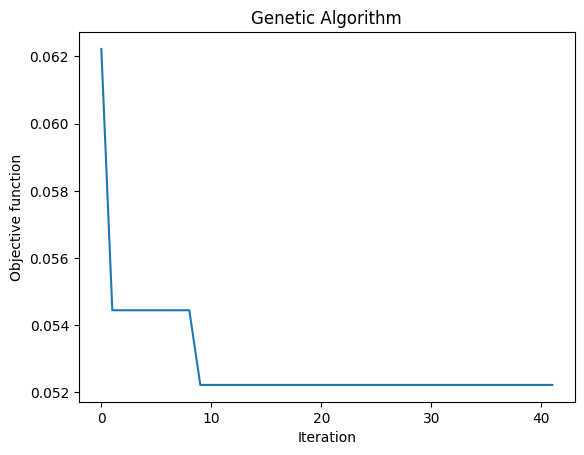

In [ ]:
model.run()

In [ ]:
# Trening najlepszego modelu

# Przypisanie wartości atrybutom algorytmu
# Zaczytanie wyniku z algrytmu ewolucyjnego

best_params = model.output_dict['variable']

hl1 = int(best_params[0])
hl2 = int(best_params[1])
learning_rate = max(float(best_params[2]), 1e-5)
solver = ['adam', 'sgd'][int(best_params[3])]
activation = ['identity', 'logistic', 'tanh', 'relu'][int(best_params[4])]

# Wybór ilość warstw ukrytych - 1 lub 2
hidden_layer_sizes = (hl1,) if hl2 == 0 else (hl1, hl2)


# Definicja parametrów perceptrona - biblioteki 'sklearn'

mlp_best = MLPClassifier(
    hidden_layer_sizes = hidden_layer_sizes,      # Rozmiar warstw ukrytych
    activation = activation,                      # Funkcja aktywacji
    alpha = 0.0001,                               # Kara za duże wartości parametrów sieci neuronowej
    max_iter = 2000,                              # Maksymalna liczba pokoleń
    random_state = 1,                             # Indeks zestawu parametrów
    solver = solver,                              # Solwer - funkcja rozwiązania
    learning_rate_init = learning_rate,           # Wsp. uczenia
    early_stopping = True,                        # Wcześniejszy stop
    n_iter_no_change = 10,                        # Ilość iteracji bez poprawy rozwiązania (w procesie uczenia)
    validation_fraction = 0.1                     # Ilość danych walidacyjnych (ocena rozwiązania)
)



In [ ]:
# Uruchomienie symulacji perceptronu
mlp_best.fit(X_train, y_train)
acc = mlp_best.score(X_test, y_test)


# Wyprowadzenie wyniku

print(f"\n Najlepszy model:")
print(f"   Warstwy: {hidden_layer_sizes}")
print(f"   Solver: {solver}")
print(f"   Learning rate: {learning_rate:.5f}")
print(f"   Aktywacja: {activation}")
print(f"   Dokładność na zbiorze testowym: {acc:.4f}")



 Najlepszy model:
   Warstwy: (3,)
   Solver: adam
   Learning rate: 0.16347
   Aktywacja: identity
   Dokładność na zbiorze testowym: 0.9556


Jedne z najlepszych wyników działania algorytmów:

Najlepszy model:
   Warstwy: (3,)
   Solver: adam
   Learning rate: 0.16911
   Aktywacja: logistic
   Dokładność na zbiorze testowym: 0.9556

Najlepszy model:
   Warstwy: (1,)
   Solver: adam
   Learning rate: 0.21248
   Aktywacja: identity
   Dokładność na zbiorze testowym: 0.9333

###**Zad. 3.** Korzystając z modelu z Zad. 2., poprzez zmiany parametrów ewolucyjnych lub uczenia MLP zweryfikuj ich wpływ na jakość modelu klasyfikacyjnego.

In [ ]:
pip install -q geneticalgorithm


 The best solution found:
 [2.         3.         0.28969774 1.         0.        ]

 Objective function:
 0.25


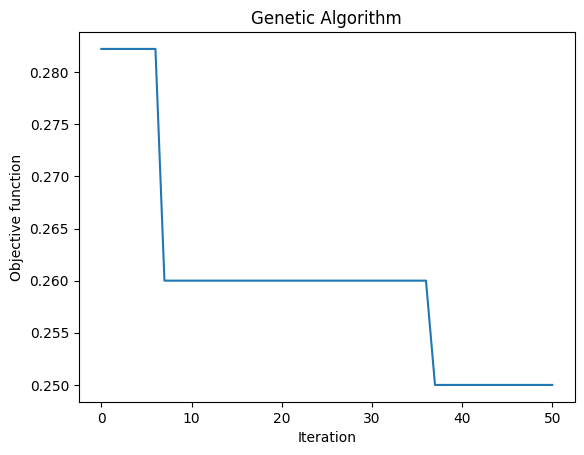


 Najlepszy model:
   Warstwy: (2, 3)
   Solver: sgd
   Learning rate: 0.28970
   Aktywacja: identity
   Dokładność na zbiorze testowym: 0.8889


In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from geneticalgorithm import geneticalgorithm as ga


# Wczytaj dane

data = load_iris()
X = data.data
y = data.target

# Poddział trening - test (relacja 70/30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# Skalowanie
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Zakres parametrów optymalizacji

var = np.array([
    [2, 10],  # Liczba neuronów w warstwie ukrytej 1          <=== Co najmniej 2 neurony
    [2, 10],  # Liczba neuronów w warstwie ukrytej 2          <=== Co najmniej 2 neurony
    [0.0001, 0.3], # Współczynnik uczenia - learning rate
    [0, 1], # Solver - optymalizator (tu: 'adam' lub 'sgd')
    [0, 3], # Funkcja aktywacji (tu: identity, logistic, tanh lub relu)
])


def fitness_function(params):         # Funkcja celu z przekazaniem parametrów
    hl1 = int(params[0])              # Ilość neuronów ukrytej warstwy 1
    hl2 = int(params[1])              # Ilość neuronów ukrytej warstwy 2
    learning_rate = max(float(params[2]), 1e-5)       # Współczynnik uczenia
    solver = ['adam', 'sgd'][int(params[3])]          # Wybór solwera
    activation = ['identity', 'logistic', 'tanh', 'relu'][int(params[4])]

    # Wybór 2 warstwy ukryte bądź jedna
    hidden_layer_sizes = (hl1,) if hl2 == 0 else (hl1, hl2)

    # Narzucanie kary
    penalty_neurons = (hl1 + hl2) / 100               # Przeciw dużym wartościom neuronów
    penalty_second_layer = 0.2 if hl2 > 0 else 0      # Przeciw dodawaniu drugiej warstwy ukrytej



    # Bezpieczne przypisanie parametrów (blok try - except)
    try:
      classifier = MLPClassifier(
          hidden_layer_sizes = hidden_layer_sizes,    # Rozmiar warstw ukrytych
          solver = solver,                            # Solwer - funkcja rozwiązania
          activation = activation,                    # Funkcja aktywacji
          learning_rate_init = learning_rate,         # Wsp. uczenia
          early_stopping = True,                      # Wcześniejszy stop
          n_iter_no_change = 10,                      # Ilość iteracji bez poprawy rozwiązania (w procesie uczenia)
          validation_fraction = 0.3,                  # Ilość danych walidacyjnych (ocena rozwiązania)
          max_iter = 2000,                            # Maksymalna liczba pokoleń
          random_state = 2)                           # Indeks zestawu parametrów

      classifier.fit(X_train, y_train)                # Uruchomenie treningu

      accuracy = classifier.score(X_test, y_test)     # Pobranie efektu

      # Kary dodatnie, accuracy ujemne (szukamy minimum)
      return 1 - accuracy + penalty_neurons + penalty_second_layer

    except ValueError:
      # Zwrócenie wyniku - (suma kar + 1) - maksymalna kara za błędne rozwiązanie
      return 1 + penalty_neurons + penalty_second_layer


# Parametry algorytmu

algorith_param = {'max_num_iteration': 50,              # Ilość iteracji
                  'population_size': 50,                # Rozmiar populacji
                  'mutation_probability': 0.01,         # Prawdopodobieństwo mutacji
                  'elit_ratio': 0.1,                    # Pula elitarna
                  'crossover_probability': 0.8,         # Prawdopodobieństwo krzyżowania
                  'parents_portion': 0.3,               # Ilość rodziców do krzyżowania
                  'crossover_type': 'one_point',        # Typ krzyżowania
                  'max_iteration_without_improv': 30}   # Limit iteracji bez polepszenia rozwiązania


model = ga(
    function = fitness_function,                  # Funkcja celu
    dimension = 5,                                # Wymiar zagadnienia (5D)
    variable_type_mixed = np.array(['int', 'int', 'real', 'int', 'int']),   # Typy zmiennych
    variable_boundaries = var,                    # Zakres parametrów inicjacji zagadnienia
    algorithm_parameters = algorith_param,        # Zestaw parametrów algorytmu
    convergence_curve = True,                     # Wykres zbieżności
    progress_bar = True                           # Pasek postępu
)


model.run()


# Trening najlepszego modelu

# Przypisanie wartości atrybutom algorytmu
# Zaczytanie wyniku z algrytmu ewolucyjnego

best_params = model.output_dict['variable']

hl1 = int(best_params[0])
hl2 = int(best_params[1])
learning_rate = max(float(best_params[2]), 1e-5)
solver = ['adam', 'sgd'][int(best_params[3])]
activation = ['identity', 'logistic', 'tanh', 'relu'][int(best_params[4])]

# Wybór ilość warstw ukrytych - 1 lub 2
hidden_layer_sizes = (hl1,) if hl2 == 0 else (hl1, hl2)


# Definicja parametrów perceptrona - biblioteki 'sklearn'

mlp_best = MLPClassifier(
    hidden_layer_sizes = hidden_layer_sizes,      # Rozmiar warstw ukrytych
    activation = activation,                      # Funkcja aktywacji
    alpha = 0.0001,                               # Kara za duże wartości parametrów sieci neuronowej
    max_iter = 2000,                              # Maksymalna liczba pokoleń
    random_state = 1,                             # Indeks zestawu parametrów
    solver = solver,                              # Solwer - funkcja rozwiązania
    learning_rate_init = learning_rate,           # Wsp. uczenia
    early_stopping = True,                        # Wcześniejszy stop
    n_iter_no_change = 10,                        # Ilość iteracji bez poprawy rozwiązania (w procesie uczenia)
    validation_fraction = 0.1                     # Ilość danych walidacyjnych (ocena rozwiązania)
)


# Uruchomienie symulacji perceptronu
mlp_best.fit(X_train, y_train)
acc = mlp_best.score(X_test, y_test)


# Wyprowadzenie wyniku

print(f"\n Najlepszy model:")
print(f"   Warstwy: {hidden_layer_sizes}")
print(f"   Solver: {solver}")
print(f"   Learning rate: {learning_rate:.5f}")
print(f"   Aktywacja: {activation}")
print(f"   Dokładność na zbiorze testowym: {acc:.4f}")



W zadaniu 3 jedyną zmianą, jakiej dokonałem było wymuszenie zastosowania w perceptronie dwóch warstw ukrytych, jako odgórnego kryterium.

Co się okazało, zbudowany w ten sposób model był nawet mniej sprawny od tego, gdzie obliczenia odbywały się na pojedynczym ukrytym neuronie. W ogólności dokładność obliczeń na zbiorze testowym dla zagadnienia z jedną warstwą ukrytą była na poziomie ~ 0.95. Natomiast wynik z wymuszoną drugą ukrytą warstwą dawał powtarzalność na poziomie ~ 0.6 - 0.9 co jest wynikiem gorszym a poza tym niestabilnym. Skutecznym okazało się prostsze rozwiązanie. Na słabszą jakość obliczeń wskazuje także wyższa wartość funkcji celu zagadnienia i jest to ~ 0.03 dla pojedynczej warstwy ukrytej oraz ~ 0.25 dla podwójnej. Różnica jest znaczna.